# Système d'Aide à la Décision — Rétention Client (Anti-Churn)
---
> **Domaine métier :** E-commerce  
> **Phase :** 2 — Collecte & Audit des Données

Cette phase couvre l'intégralité du point 2 du cahier des charges :
cartographie des sources, audit complet, évaluation des biais et données fantômes,
Data Dictionary, et stratégie d'imputation. Conformément aux contraintes, **deux
sources de données réelles sont combinées** (Kaggle + UCI).


## 0. Environnement & Imports

Les fonctions de traitement sont regroupées dans le module `src/preprocessing.py`.


In [1]:
import sys
from pathlib import Path

# Racine du projet : on remonte jusqu'au dossier contenant `src`
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import preprocessing as dp

IMAGES = ROOT / "images"
PROCESSED = ROOT / "data" / "processed"
IMAGES.mkdir(exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

# Palette de couleurs
C_INDIGO, C_RED, C_GREEN, C_AMBER = "#6366f1", "#ef4444", "#22c55e", "#f59e0b"
print("Environnement prêt — pandas", pd.__version__)

Environnement prêt — pandas 3.0.2


## 1. Cartographie des Sources de Données

Le cahier des charges impose **au moins 2 sources différentes à combiner** et un
**volume minimum de 50 000 lignes brutes**. Nous combinons deux jeux de données
transactionnels réels, complémentaires sur la période couverte :

| # | Source | Type | Format | Volume brut | Période |
|---|--------|------|--------|-------------|---------|
| 1 | **Kaggle — E-Commerce Data** | Transactionnelle | CSV | **541 909 lignes** | 2010-2011 |
| 2 | **UCI — Online Retail II** | Transactionnelle | Excel (2 feuilles) | **1 067 371 lignes** | 2009-2011 |

Les deux sources partagent le même schéma métier (facture, produit, quantité,
prix, client, pays) mais couvrent des périodes différentes. On les **harmonise**
(noms de colonnes alignés) puis on les **concatène**. Un référentiel
[REST Countries](https://restcountries.com/) ajoute ensuite région, sous-région
et population par pays.

- **Source 1** : <https://www.kaggle.com/datasets/carrie1/ecommerce-data>
- **Source 2** : <https://archive.ics.uci.edu/dataset/502/online+retail+ii>


In [2]:
kaggle = dp.load_kaggle()
uci = dp.load_uci()
print("Source 1 — Kaggle :", kaggle.shape, "| période",
      kaggle['InvoiceDate'].min(), "->", kaggle['InvoiceDate'].max())
print("Source 2 — UCI II :", uci.shape, "| période",
      uci['InvoiceDate'].min(), "->", uci['InvoiceDate'].max())
kaggle.head()

Source 1 — Kaggle : (541909, 9) | période 2010-12-01 08:26:00 -> 2011-12-09 12:50:00
Source 2 — UCI II : (1067371, 9) | période 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Source
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Kaggle_ecommerce
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Kaggle_ecommerce
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Kaggle_ecommerce
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Kaggle_ecommerce
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Kaggle_ecommerce


### 1.1 Combinaison des deux sources

In [3]:
raw = dp.load_raw()
print("Dimensions brutes combinées :", raw.shape)
print("Volume minimum (50 000) respecté :", len(raw) >= 50_000)
print("\nRépartition par source :")
print(raw["Source"].value_counts())
raw.head()

Dimensions brutes combinées : (1609280, 9)
Volume minimum (50 000) respecté : True

Répartition par source :
Source
UCI_OnlineRetailII    1067371
Kaggle_ecommerce       541909
Name: count, dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Source
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Kaggle_ecommerce
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Kaggle_ecommerce
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Kaggle_ecommerce
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Kaggle_ecommerce
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Kaggle_ecommerce


## 2. Data Audit Complet

On évalue les 6 dimensions de qualité attendues : **complétude, cohérence,
fraîcheur, granularité, doublons** et **données fantômes**.


### 2.1 Complétude, types et cardinalité par colonne

In [4]:
audit = dp.audit_report(raw)
audit

,Colonne,Type,Manquants_%,Uniques,Exemple
0,Invoice,object,0.00,75689,536365
1,StockCode,object,0.00,8251,85123A
2,Description,object,0.36,5699,WHITE HANGING HEART T-LIGHT HOLDER
3,Quantity,int64,0.00,1057,6
4,InvoiceDate,datetime64[us],0.00,47635,2010-12-01 08:26:00
5,UnitPrice,float64,0.00,2807,2.55
6,CustomerID,float64,23.49,5942,17850.0
7,Country,str,0.00,43,United Kingdom
8,Source,str,0.00,2,Kaggle_ecommerce


### 2.2 Cohérence, fraîcheur & données fantômes

On quantifie ici les anomalies métier. Le point clé propre à une combinaison de
deux sources : les **doublons cross-source**. La période 2010-2011 étant présente
dans les deux jeux, certaines transactions sont strictement identiques — l'audit
les détecte explicitement avant de les supprimer.


In [5]:
flags = dp.quality_flags(raw)
for k, v in flags.items():
    print(f"{k:>28} : {v}")

                      lignes : 1609280
       doublons_cross_source : 40844
            sans_customer_id : 378087
  quantite_negative_ou_nulle : 33574
         prix_negatif_ou_nul : 8724
                 annulations : 28782
                    date_min : 2009-12-01 07:45:00
                    date_max : 2011-12-09 12:50:00
              pays_distincts : 43


### 2.3 Visualisation du taux de valeurs manquantes

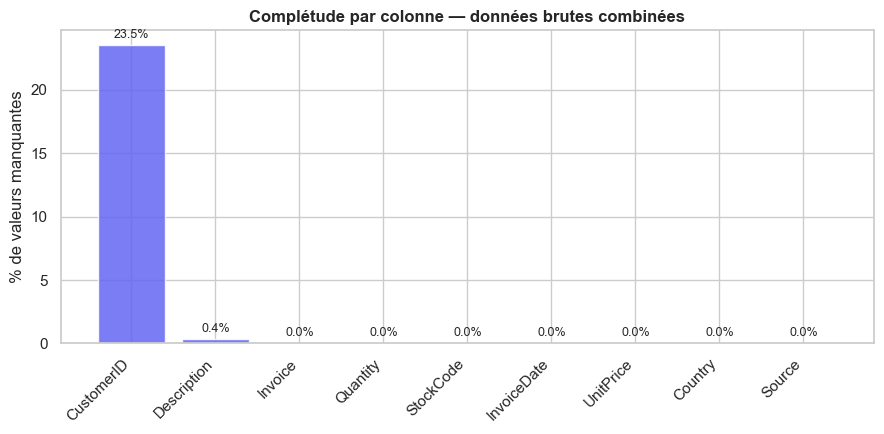

In [6]:
miss = (raw.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(miss.index, miss.values, color=C_INDIGO, alpha=0.85)
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.set_ylabel("% de valeurs manquantes")
ax.set_title("Complétude par colonne — données brutes combinées", fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(IMAGES / "phase2_missing_values.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Apport et chevauchement des deux sources

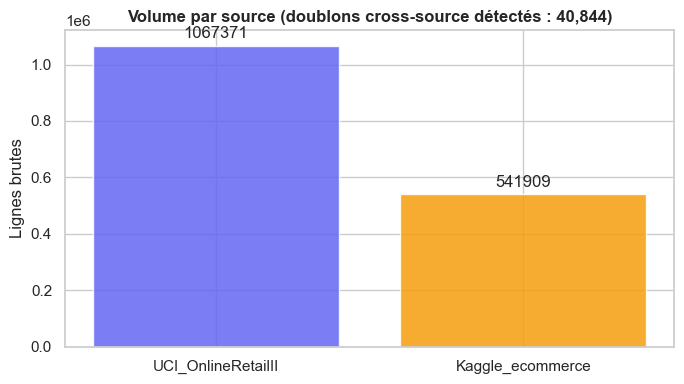

In [7]:
n_dup = dp.count_cross_source_duplicates(raw)
fig, ax = plt.subplots(figsize=(7, 4))
counts = raw["Source"].value_counts()
bars = ax.bar(counts.index, counts.values, color=[C_INDIGO, C_AMBER], alpha=0.85)
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_ylabel("Lignes brutes")
ax.set_title(f"Volume par source (doublons cross-source détectés : {n_dup:,})",
             fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES / "phase2_sources.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5 Évaluation des biais potentiels

> **Biais géographique :** la base est très majoritairement britannique (marchand
> UK). Toute conclusion « marché international » doit être interprétée avec prudence.
>
> **Biais de chevauchement temporel :** la période 2010-2011 est présente dans les
> deux sources. La dédup cross-source neutralise les transactions strictement
> identiques, mais ce chevauchement reste documenté comme une limite connue.


Part du Royaume-Uni dans les lignes brutes : 91.8%


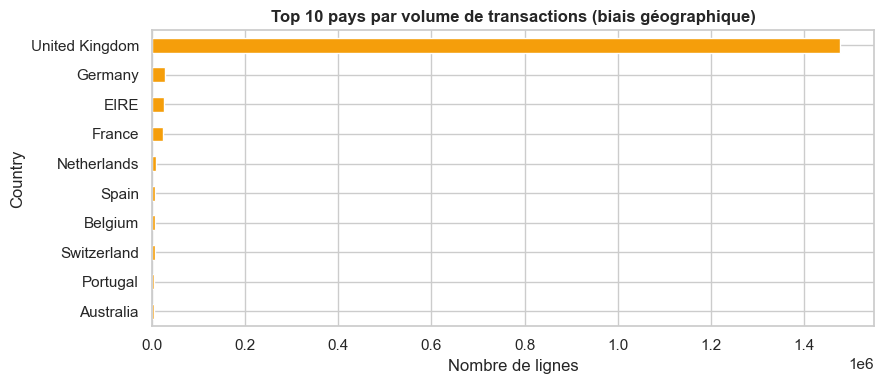

In [8]:
top_countries = raw["Country"].value_counts().head(10)
share_uk = top_countries.get("United Kingdom", 0) / len(raw)
print(f"Part du Royaume-Uni dans les lignes brutes : {share_uk:.1%}")
fig, ax = plt.subplots(figsize=(9, 4))
top_countries.plot(kind="barh", color=C_AMBER, ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Nombre de lignes")
ax.set_title("Top 10 pays par volume de transactions (biais géographique)", fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES / "phase2_country_bias.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Data Dictionary

Documentation complète de chaque variable du schéma harmonisé : nom, type,
description, source et valeurs possibles. Les variables marquées *(dérivée)* sont
créées lors du nettoyage / enrichissement.


| Variable | Type | Description | Source | Valeurs possibles |
|----------|------|-------------|--------|-------------------|
| `Invoice` | str | N° de facture (préfixe `C` = annulation) | Kaggle + UCI | 6 chiffres, ou `C` + 6 chiffres |
| `StockCode` | str | Code produit | Kaggle + UCI | ~5 000 codes (+ codes techniques : `POST`, `DOT`, `M`…) |
| `Description` | str | Libellé produit | Kaggle + UCI | Texte libre |
| `Quantity` | int | Quantité achetée par ligne | Kaggle + UCI | Entier (négatif = retour) |
| `InvoiceDate` | datetime | Date et heure de la transaction | Kaggle + UCI | 2009-12-01 → 2011-12-09 |
| `UnitPrice` | float | Prix unitaire (£) | Kaggle + UCI | Réel ≥ 0 |
| `CustomerID` | int | Identifiant client | Kaggle + UCI | ~5 900 clients (~23 % manquants) |
| `Country` | str | Pays de livraison | Kaggle + UCI | 43 libellés |
| `Source` | str | Source d'origine de la ligne *(dérivée)* | Pipeline | `Kaggle_ecommerce`, `UCI_OnlineRetailII` |
| `TotalPrice` | float | `Quantity × UnitPrice` *(dérivée)* | Pipeline | Réel > 0 |
| `Region` | str | Région du pays *(dérivée)* | REST Countries | Europe, Americas, Asia… |
| `SubRegion` | str | Sous-région *(dérivée)* | REST Countries | Northern Europe… |
| `Population` | float | Population du pays *(dérivée)* | REST Countries | Entier |
| `Lat`, `Lng` | float | Coordonnées du pays *(dérivées)* | REST Countries | Réels |


## 4. Gaps Data & Stratégie d'Imputation

| Gap identifié | Décision | Justification |
|---------------|----------|---------------|
| Doublons cross-source (période commune) | **Suppression** | Transactions strictement identiques présentes dans les 2 sources. |
| `CustomerID` manquant (~23 %) | **Suppression** | L'analyse de churn est centrée client : une ligne sans client est inexploitable. L'imputation créerait de faux clients. |
| `Description` manquante (<0,5 %) | **Conservation** | Sans impact sur l'agrégation RFM (basée sur montants/dates). |
| `Quantity ≤ 0` / annulations | **Suppression** | Retours et avoirs ne reflètent pas un achat. |
| `UnitPrice ≤ 0` | **Suppression** | Lignes techniques (ajustements, échantillons). |
| Pays `Unspecified` | **Non enrichi (NaN géo)** | Aucune correspondance fiable possible. |

> Le choix dominant est la **suppression maîtrisée** plutôt que l'imputation : sur
> une base transactionnelle, imputer un identifiant client ou un prix introduirait
> un biais bien plus dommageable que la perte de lignes non exploitables.


## 5. Application du Nettoyage (dédup cross-source + règles métier)

In [9]:
clean = dp.clean_transactions(raw)
print("Avant :", raw.shape[0], "lignes (2 sources combinées)")
print("Après :", clean.shape[0], "lignes exploitables")
print(f"Réduction : {1 - len(clean)/len(raw):.1%}")
print("Clients uniques :", clean["CustomerID"].nunique())
print("Pays uniques    :", clean["Country"].nunique())
print(f"CA total        : £{clean['TotalPrice'].sum():,.2f}")
print("\nRépartition finale par source :")
print(clean["Source"].value_counts())
clean.head()

Avant : 1609280 lignes (2 sources combinées)
Après : 1172113 lignes exploitables
Réduction : 27.2%
Clients uniques : 5878
Pays uniques    : 41
CA total        : £26,260,909.46

Répartition finale par source :
Source
UCI_OnlineRetailII    779423
Kaggle_ecommerce      392690
Name: count, dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Source,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Kaggle_ecommerce,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Kaggle_ecommerce,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Kaggle_ecommerce,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Kaggle_ecommerce,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Kaggle_ecommerce,20.34


## 6. Enrichissement Géographique (Référentiel Pays)

On interroge l'API REST Countries puis on joint les dimensions géographiques aux
transactions nettoyées.


In [10]:
countries = dp.fetch_country_reference()
print("Référentiel pays récupéré :", countries.shape)
countries.head()

Référentiel pays récupéré : (250, 6)


,CountryAPI,Region,SubRegion,Population,Lat,Lng
0,Anguilla,Americas,Caribbean,16010,18.250000,-63.166667
1,Guatemala,Americas,Central America,18079810,15.500000,-90.250000
2,Gambia,Africa,Western Africa,2422712,13.466667,-16.566667
3,Mexico,Americas,North America,130575786,23.000000,-102.000000
4,Malawi,Africa,Eastern Africa,20734262,-13.500000,34.000000


In [11]:
enriched = dp.enrich(clean, countries)
match_rate = enriched["Region"].notna().mean()
print(f"Taux d'appariement géographique : {match_rate:.2%}")
unmatched = sorted(enriched.loc[enriched["Region"].isna(), "Country"].unique())
print("Libellés non appariés :", unmatched)
enriched[["Country", "Region", "SubRegion", "Population", "TotalPrice"]].head()

Taux d'appariement géographique : 99.94%
Libellés non appariés : ['Unspecified']


,Country,Region,SubRegion,Population,TotalPrice
0,United Kingdom,Europe,Northern Europe,69281437.0,15.30
1,United Kingdom,Europe,Northern Europe,69281437.0,20.34
2,United Kingdom,Europe,Northern Europe,69281437.0,22.00
3,United Kingdom,Europe,Northern Europe,69281437.0,20.34
4,United Kingdom,Europe,Northern Europe,69281437.0,20.34


### 6.1 Répartition du chiffre d'affaires par région

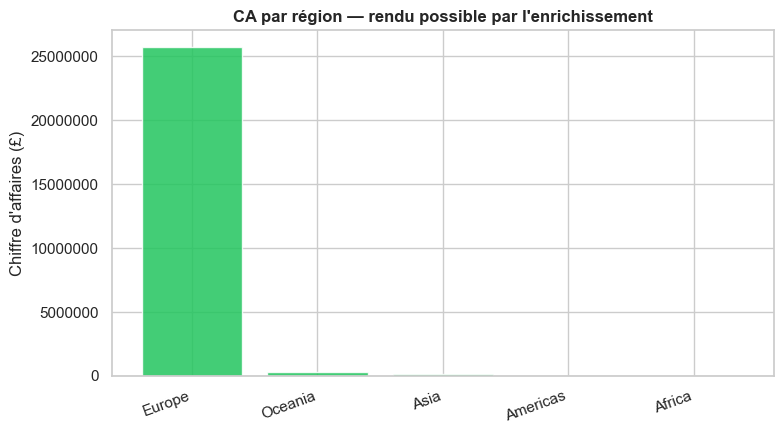

Region
Europe      2.574969e+07
Oceania     3.077373e+05
Asia        1.655441e+05
Americas    2.358855e+04
Africa      3.076440e+03
Name: TotalPrice, dtype: float64

In [12]:
ca_region = (enriched.groupby("Region")["TotalPrice"]
             .sum().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(ca_region.index, ca_region.values, color=C_GREEN, alpha=0.85)
ax.set_ylabel("Chiffre d'affaires (£)")
ax.set_title("CA par région — rendu possible par l'enrichissement", fontweight="bold")
ax.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(IMAGES / "phase2_ca_by_region.png", dpi=150, bbox_inches="tight")
plt.show()
ca_region

## 7. Sauvegarde du Dataset Final

Le dataset nettoyé et enrichi est persisté dans `data/processed/` pour servir de
point d'entrée à la Phase 3 (EDA & analyse statistique).


In [13]:
out_path = PROCESSED / "clean_transactions.csv"
enriched.to_csv(out_path, index=False)
print("Sauvegardé →", out_path.relative_to(ROOT))
print("Dimensions finales :", enriched.shape)

Sauvegardé → data\processed\clean_transactions.csv
Dimensions finales : (1172113, 16)


## 8. Conclusion

La phase de collecte et d'audit des données est aboutie. Deux jeux de données
transactionnels réels ont été cartographiés, harmonisés sur un schéma commun puis
combinés : Kaggle E-Commerce (541 909 lignes) et UCI Online Retail II (1 067 371
lignes), pour un volume brut d'environ 1,6 million de lignes.

L'audit a mis en évidence les principales limites de qualité : un chevauchement
temporel entre les deux sources sur 2010-2011 générant des transactions strictement
identiques, environ 23 % d'identifiants client manquants, ainsi que des annulations
et des lignes techniques. Ces constats ont guidé une stratégie de traitement fondée
sur la suppression maîtrisée plutôt que sur l'imputation, afin de ne pas introduire
de biais sur une base transactionnelle.

Après dédoublonnage cross-source et application des règles métier, le jeu de données
exploitable atteint environ 1,17 million de lignes. L'enrichissement géographique
via le référentiel pays couvre 99,9 % des lignes (région, sous-région, population).
Le résultat est consolidé dans `data/processed/clean_transactions.csv`, un jeu de
données propre, documenté et traçable par source, qui constitue une base fiable
pour les analyses suivantes.
